# Long Short-Term Memory (LSTM)
## 1. LSTM là gì?

LSTM (Long Short-Term Memory) là một biến thể đặc biệt của mạng nơ-ron hồi quy (**Recurrent Neural Network - RNN**), được thiết kế để xử lý dữ liệu dạng chuỗi (**sequence**) như văn bản, âm thanh hoặc chuỗi thời gian.

So với RNN thông thường, LSTM hoạt động tốt hơn khi cần giữ thông tin qua nhiều bước thời gian, nhờ cơ chế **Cell State** và các **cổng (gates)** giúp chọn lọc thông tin nên giữ, nên cập nhật hay nên đưa ra đầu ra. Nhờ đó, LSTM giảm ảnh hưởng của vấn đề **vanishing gradient** và xử lý tốt hơn các quan hệ phụ thuộc dài hạn trong chuỗi.

LSTM giúp giảm ảnh hưởng của vấn đề vanishing gradient nhờ cơ chế cập nhật Cell State theo dạng cộng:
$$
C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
$$
Thay vì chỉ lặp lại các phép biến đổi nhân qua nhiều bước như trong RNN truyền thống, cấu trúc cộng này giúp thông tin và đạo hàm được truyền ổn định hơn qua chuỗi, từ đó hỗ trợ mô hình học các phụ thuộc dài hạn tốt hơn.

**Ví dụ**: Khi đọc một câu dài như:  
*"Tôi đã gặp một người bạn cũ, người mà tôi không gặp từ hồi tiểu học, và chúng tôi đã trò chuyện rất vui"*,  
ta vẫn có thể liên hệ cụm *"người bạn cũ"* ở đầu câu với phần sau của câu để hiểu ý nghĩa toàn bộ. LSTM cũng được thiết kế để duy trì những thông tin quan trọng như vậy khi xử lý dữ liệu chuỗi.

**Ví dụ cụ thể**: Trong bài toán dự đoán từ tiếp theo với câu  
*"Tôi thích nghe nhạc..."*,  
LSTM không chỉ dựa vào từ cuối cùng là *"nhạc"*, mà còn tận dụng ngữ cảnh trước đó như *"thích"* và *"nghe"* để dự đoán từ tiếp theo hợp lý, chẳng hạn như *"pop"*, *"rock"* hoặc một cụm từ phù hợp khác.

## 2. Các thành phần chính của LSTM

LSTM hoạt động dựa trên ba cổng chính: **Forget Gate**, **Input Gate**, và **Output Gate**, cùng với một **Cell State** đóng vai trò truyền và cập nhật thông tin quan trọng qua nhiều bước thời gian.

- **Vai trò của các hàm kích hoạt**:
  - **Sigmoid** ($\sigma$) được dùng trong các cổng vì đầu ra nằm trong khoảng $[0,1]$, phù hợp để biểu diễn mức độ giữ lại, bổ sung hoặc xuất ra thông tin.
  - **tanh** được dùng để biểu diễn nội dung trạng thái vì đầu ra nằm trong khoảng $[-1,1]$, giúp giữ giá trị trong một miền ổn định hơn.

### 2.1. Cell State (Trạng thái ô nhớ)

- **Ý tưởng**: Cell State là trạng thái trung tâm của LSTM, giúp mang thông tin xuyên suốt chuỗi dữ liệu. Ở mỗi bước thời gian, trạng thái này được cập nhật bằng cách giữ lại thông tin còn hữu ích và bổ sung thông tin mới khi cần.

- **Lưu ý**: Cell State không lưu trực tiếp câu chữ như con người ghi nhớ văn bản, mà lưu một **biểu diễn số học của ngữ cảnh**. Vì vậy, khi nói Cell State “nhớ” thông tin, đó là cách diễn đạt trực quan để dễ hiểu.

- **Ví dụ**: Trong câu  
  *"Tôi thích nghe nhạc pop và ăn đồ Hàn"*,  
  Cell State có thể dần mã hóa ngữ cảnh rằng người nói đang đề cập đến các sở thích liên quan đến **âm nhạc** và **ăn uống**. Khi xử lý đến các từ phía sau, LSTM không quên hoàn toàn thông tin trước đó mà tiếp tục cập nhật ngữ cảnh tổng thể.

- **Hình minh họa**:

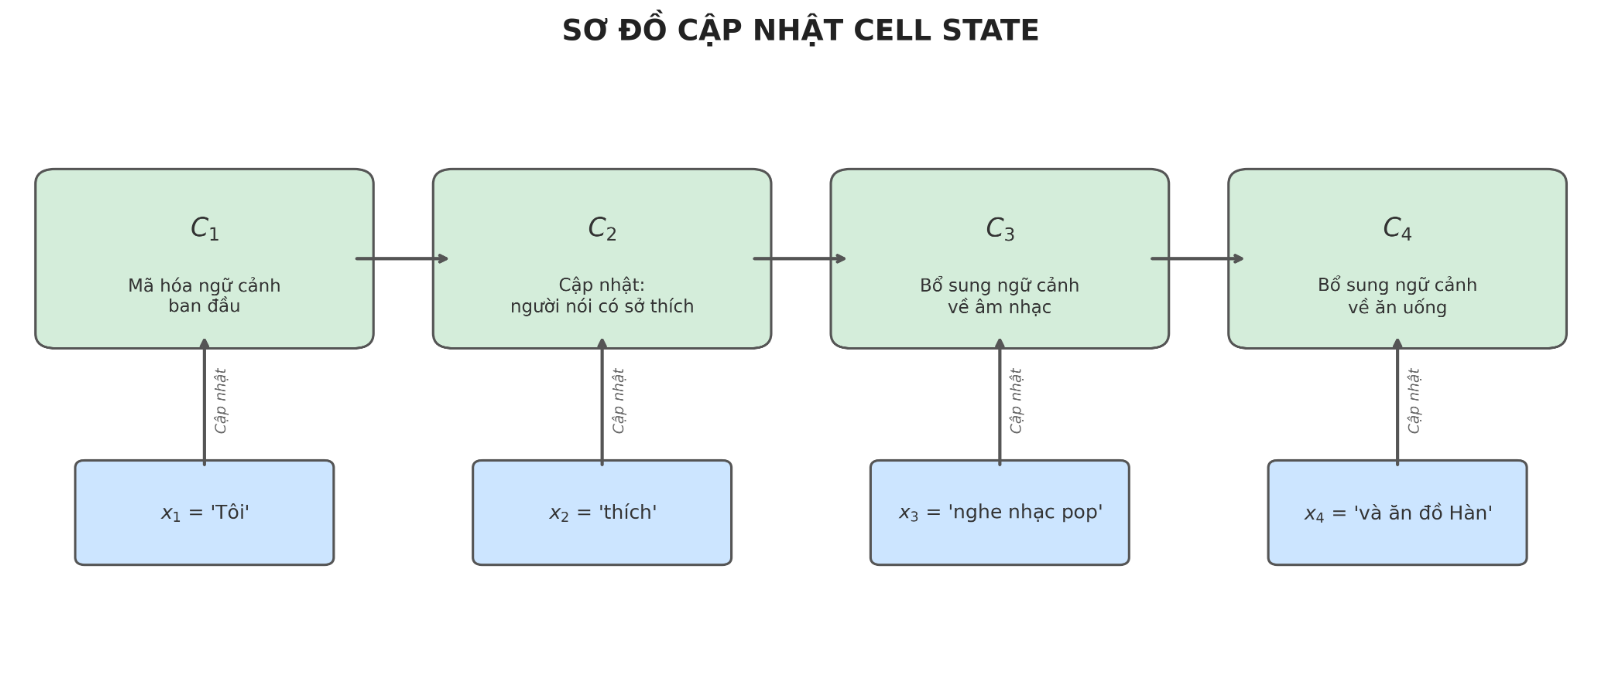

### 2.2. Forget Gate (Cổng quên)

- **Ý tưởng**: Forget Gate quyết định **mức độ giữ lại hay loại bớt thông tin cũ** trong Cell State từ bước thời gian trước. Cơ chế này giúp LSTM giảm ảnh hưởng của những thông tin không còn hữu ích đối với ngữ cảnh hiện tại.

- **Công thức**:
  $$
  f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
  $$
  Trong đó:
  - $f_t$: vector cổng quên tại thời điểm $t$, có giá trị trong khoảng từ 0 đến 1.
  - $\sigma$: hàm sigmoid, dùng để đưa các giá trị về khoảng 0 đến 1.
  - $h_{t-1}$: Hidden State ở bước trước.
  - $x_t$: đầu vào tại bước hiện tại.
  - $W_f, b_f$: trọng số và bias được mô hình học trong quá trình huấn luyện.

- **Giải thích**:
  - $[h_{t-1}, x_t]$ là phép nối hai vector lại với nhau (**concatenation**).
  - Sau khi nhân với trọng số và cộng bias, kết quả được đưa qua hàm sigmoid để tạo ra $f_t$.
  - Mỗi phần tử của $f_t$ cho biết **nên giữ lại bao nhiêu** thông tin tương ứng trong Cell State cũ:
    - giá trị gần **1**: giữ lại gần như toàn bộ,
    - giá trị gần **0**: loại bỏ phần lớn thông tin đó.
  - Vì vậy, Forget Gate không “xóa” nguyên một từ hay một ý theo kiểu rời rạc, mà **điều chỉnh mức độ giữ lại các thành phần thông tin trong biểu diễn trạng thái**.

- **Ví dụ**:  
  Giả sử mô hình đang xử lý chuỗi:
  *"Tôi thích nghe nhạc, nhưng hôm nay tôi muốn xem phim."*  
  Khi gặp ngữ cảnh mới liên quan đến *"xem phim"*, Forget Gate có thể làm giảm ảnh hưởng của một số thông tin trước đó liên quan đến *"nghe nhạc"* nếu chúng không còn quan trọng cho dự đoán ở thời điểm hiện tại.

- **Hình**

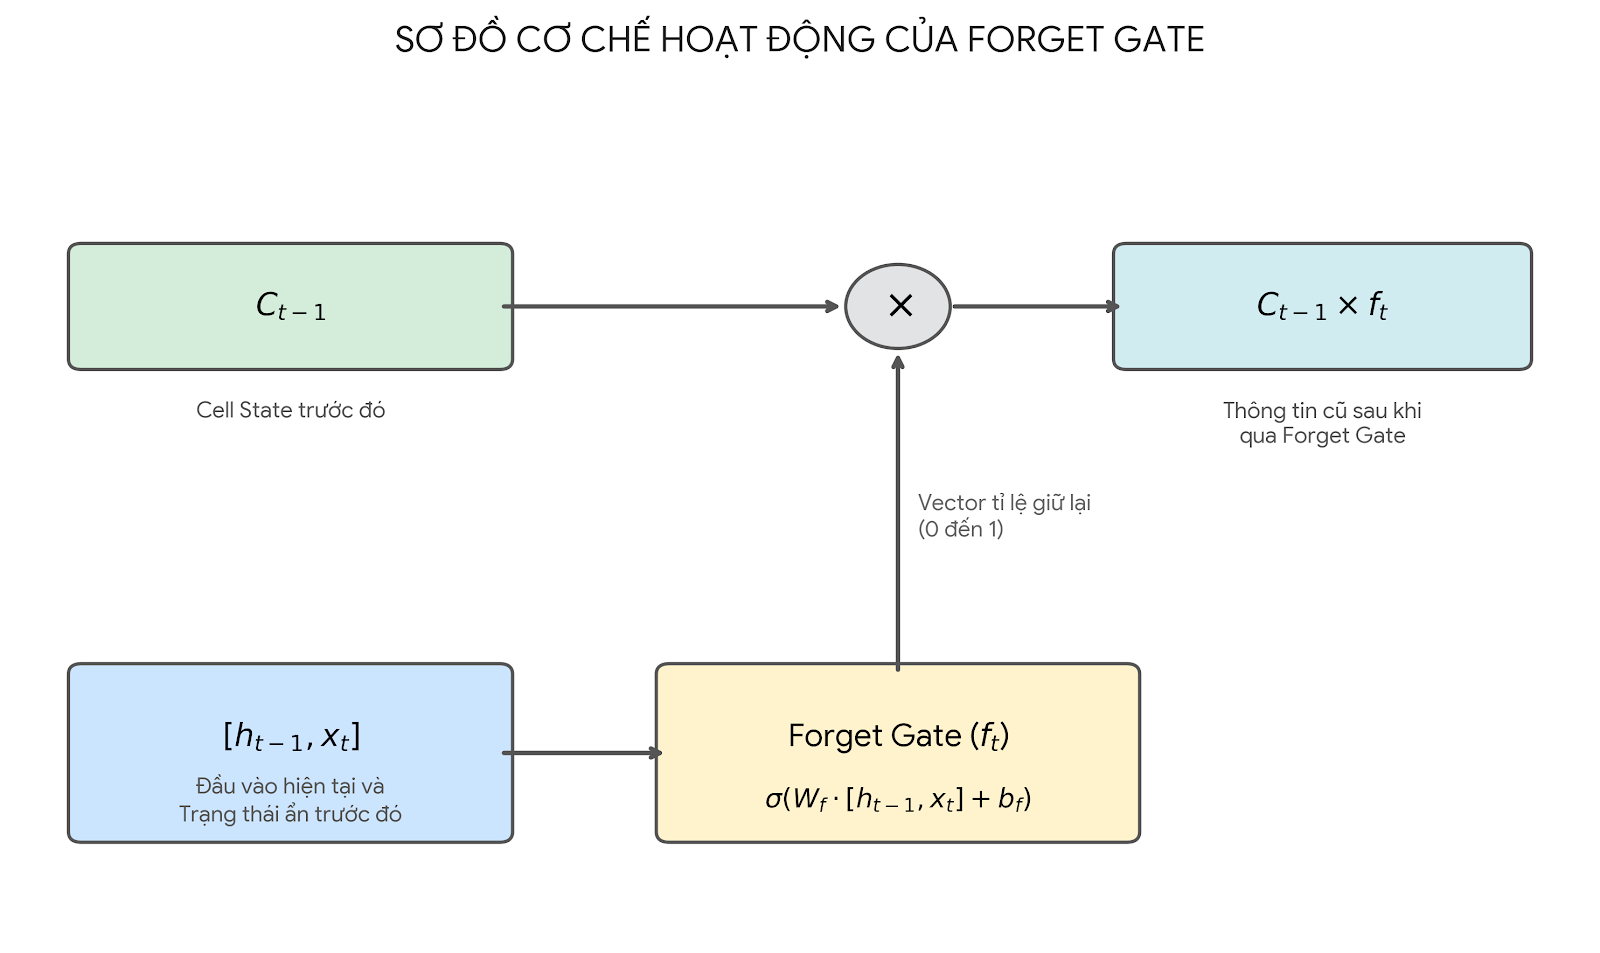

### 2.3. Input Gate (Cổng vào)

- **Ý tưởng**: Input Gate quyết định **mức độ thông tin mới sẽ được thêm vào Cell State** tại thời điểm hiện tại. Cơ chế này giúp LSTM cập nhật ngữ cảnh bằng cách chọn lọc những thông tin mới thực sự hữu ích.

- **Công thức**:
  $$
  i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
  $$
  $$
  \tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
  $$
  $$
  C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
  $$

  Trong đó:
  - $i_t$: vector cổng nhập tại thời điểm $t$, có giá trị trong khoảng từ 0 đến 1, cho biết mức độ chấp nhận thông tin mới.
  - $\tilde{C}_t$: vector ứng viên thông tin mới (**candidate cell state**), biểu diễn nội dung mới có thể được thêm vào Cell State.
  - $C_t$: Cell State mới sau khi kết hợp thông tin cũ và thông tin mới.
  - $f_t \cdot C_{t-1}$: phần thông tin cũ còn được giữ lại sau Forget Gate.
  - $i_t \cdot \tilde{C}_t$: phần thông tin mới được chọn để thêm vào Cell State.
  - $W_i, W_C, b_i, b_C$: các tham số được học trong quá trình huấn luyện.
- **Lưu ý ký hiệu**: Trong các biểu thức như $f_t \cdot C_{t-1}$ hay $i_t \cdot \tilde{C}_t$, dấu $\cdot$ là **phép nhân từng phần tử** (**element-wise / Hadamard product**), không phải nhân ma trận hay tích vô hướng.
- **Giải thích**:
  - $[h_{t-1}, x_t]$ là phép nối (**concatenation**) giữa Hidden State ở bước trước và đầu vào hiện tại.
  - Từ đầu vào này, mô hình tính ra:
    - $i_t$ để quyết định **nên thêm bao nhiêu** thông tin mới,
    - $\tilde{C}_t$ để biểu diễn **nội dung mới đề xuất**.
  - Sau đó, Cell State mới được cập nhật bằng cách:
    - giữ lại một phần thông tin cũ từ $C_{t-1}$ thông qua Forget Gate,
    - cộng thêm phần thông tin mới được chọn lọc thông qua Input Gate.
  - Vì vậy, Input Gate không đơn thuần “chèn thêm một từ”, mà điều chỉnh **mức độ đưa thông tin mới vào biểu diễn trạng thái**.

- **Ví dụ**:  
  Với chuỗi:
  *"Tôi thích nghe nhạc pop"*,  
  khi mô hình xử lý đến từ *"pop"*, Input Gate có thể cho phép bổ sung mạnh hơn các đặc trưng liên quan đến **thể loại nhạc** vào Cell State, giúp mô hình cập nhật ngữ cảnh cụ thể hơn về sở thích của người nói.

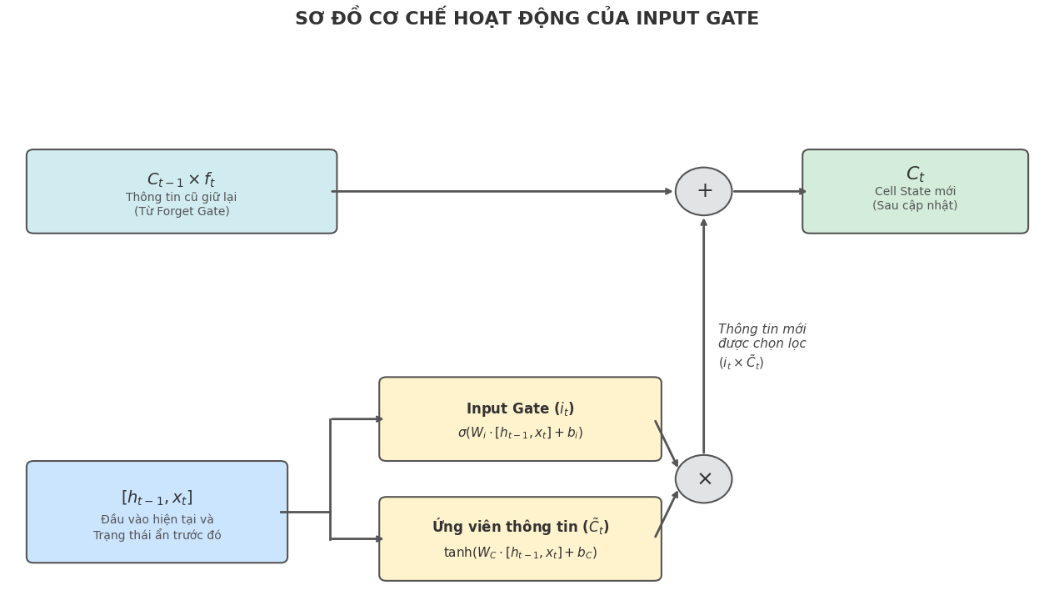

### 2.4. Output Gate (Cổng ra)

- **Ý tưởng**: Output Gate quyết định **phần thông tin nào từ Cell State sẽ được đưa ra ngoài** để tạo thành Hidden State tại thời điểm hiện tại. Hidden State này vừa là đầu ra của bước hiện tại, vừa được truyền sang bước tiếp theo để hỗ trợ tính toán.

- **Công thức**:
  $$
  o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
  $$
  $$
  h_t = o_t \cdot \tanh(C_t)
  $$

  Trong đó:
  - $o_t$: vector cổng xuất tại thời điểm $t$, có giá trị trong khoảng từ 0 đến 1, dùng để quyết định mức độ đưa thông tin từ Cell State ra ngoài.
  - $C_t$: Cell State tại thời điểm hiện tại.
  - $\tanh(C_t)$: phiên bản đã được nén của Cell State về khoảng từ -1 đến 1.
  - $h_t$: Hidden State mới, đồng thời là đầu ra của bước hiện tại.
  - $W_o, b_o$: các tham số được học trong quá trình huấn luyện.

- **Giải thích chi tiết**:
  - Từ $[h_{t-1}, x_t]$, mô hình tính ra $o_t$ thông qua hàm sigmoid.
  - Đồng thời, Cell State hiện tại $C_t$ được đưa qua hàm $\tanh$ để tạo ra một biểu diễn phù hợp cho đầu ra.
  - Sau đó, Output Gate dùng $o_t$ để chọn lọc phần nào của $\tanh(C_t)$ sẽ được đưa ra ngoài thành $h_t$.
  - Vì vậy, Output Gate không xuất toàn bộ Cell State, mà chỉ cho phép **một phần thông tin đã được chọn lọc** đi vào Hidden State.
  
  **Lưu ý**: Trong cách giải thích trực quan, $h_t$ thường được xem như dạng **bộ nhớ ngắn hạn** vì nó là thông tin được xuất ra tại thời điểm hiện tại và truyền sang bước kế tiếp. Trong khi đó, $C_t$ đóng vai trò mang thông tin dài hạn hơn xuyên suốt chuỗi. Đây cũng là ý tưởng đứng sau tên gọi **Long Short-Term Memory**.

- **Ví dụ**:  
  Với chuỗi:
  *"Tôi thích nghe nhạc"*,  
  khi mô hình xử lý đến từ cuối của chuỗi, Output Gate có thể làm nổi bật các đặc trưng liên quan đến **sở thích nghe nhạc** trong Hidden State, từ đó hỗ trợ dự đoán từ tiếp theo phù hợp.

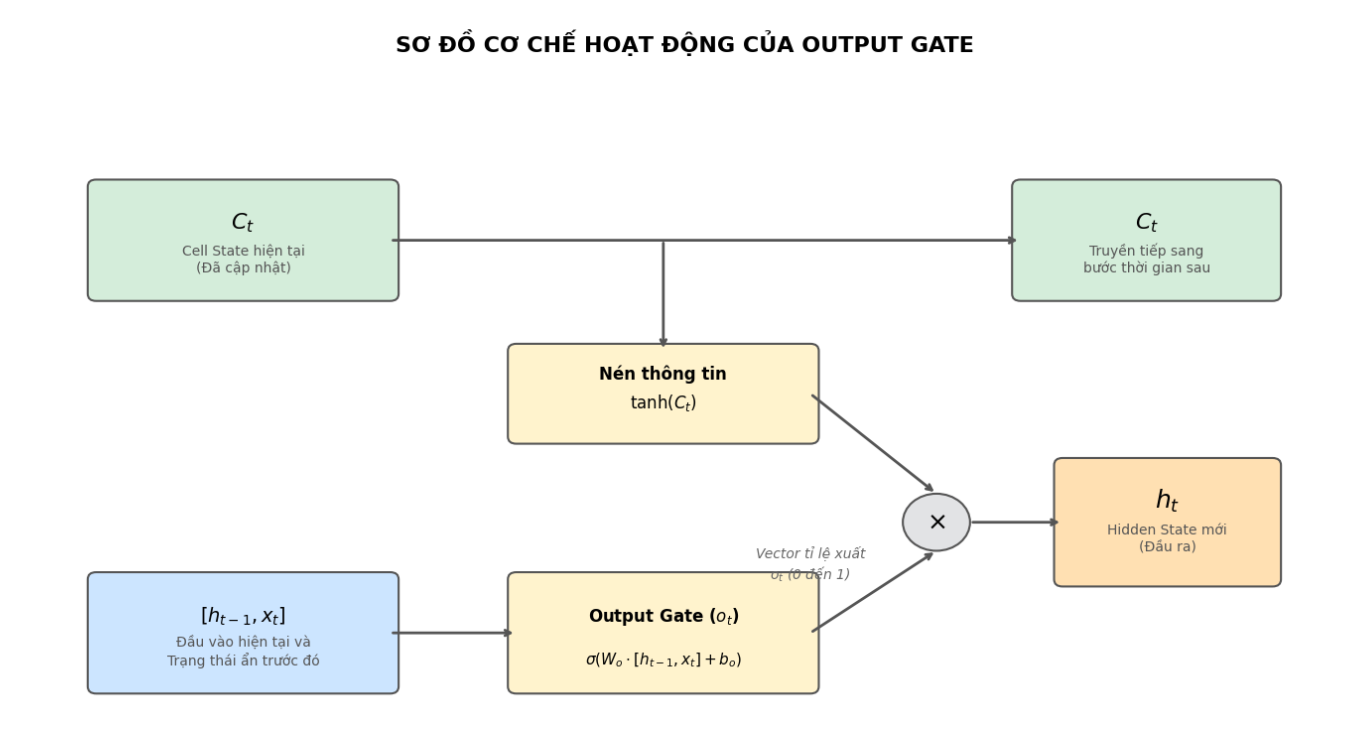


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Dữ liệu giả lập: từ vựng và câu
vocab = {
    "I": 1,
    "like": 2,
    "to": 3,
    "music": 4,
    "not": 5,
    "sad": 6,
    "happy": 7,
}  # Từ điển từ
sentences = [
    ([1, 2, 3, 4], 1),  # "I like to music" -> tích cực (1)
    ([1, 5, 2, 6], 0),  # "I not like sad" -> tiêu cực (0)
    ([1, 2, 7], 1),  # "I like happy" -> tích cực (1)
]
data = [
    (torch.tensor(seq, dtype=torch.long), torch.tensor(label, dtype=torch.long))
    for seq, label in sentences
]

In [2]:
# Định nghĩa mô hình LSTM
class SimpleLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(SimpleLSTM, self).__init__()
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim
        )  # Chuyển từ thành vector
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)  # Tầng LSTM
        self.fc = nn.Linear(hidden_dim, output_dim)  # Tầng fully connected

    def forward(self, text):
        embedded = self.embedding(
            text
        )  # Từ -> vector (batch_size, seq_len, embedding_dim)
        output, (hidden, cell) = self.lstm(
            embedded
        )  # Qua LSTM, lấy hidden và cell state
        return self.fc(hidden[-1])  # Dùng hidden state cuối cùng để phân loại

In [3]:
# Khởi tạo mô hình
model = SimpleLSTM(
    vocab_size=len(vocab) + 1, embedding_dim=10, hidden_dim=20, output_dim=2
)
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

In [4]:
# Huấn luyện mô hình
loss_values = []
for epoch in range(50):
    total_loss = 0
    for seq, label in data:
        optimizer.zero_grad()
        seq = seq.unsqueeze(0)  # Thêm chiều batch
        label = label.unsqueeze(0)  # Thêm chiều batch
        output = model(seq)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_values.append(total_loss / len(data))
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss / len(data):.4f}")

Epoch 0, Loss: 0.7047
Epoch 10, Loss: 0.5159
Epoch 20, Loss: 0.2516
Epoch 30, Loss: 0.0959
Epoch 40, Loss: 0.0476


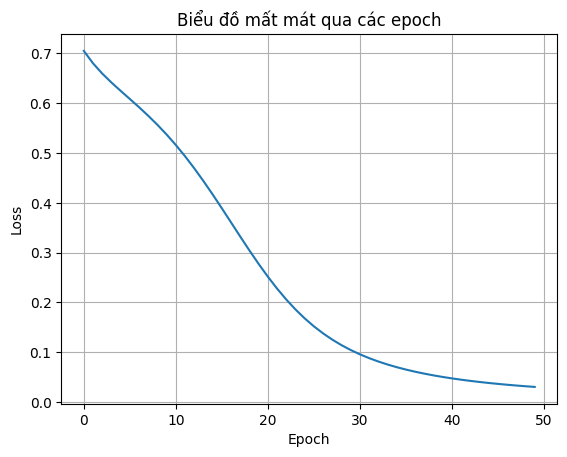

In [5]:
# Vẽ biểu đồ loss
plt.plot(range(50), loss_values)
plt.title("Biểu đồ mất mát qua các epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [6]:
# Dự đoán
model.eval()
test_seq = torch.tensor([1, 2, 3, 4], dtype=torch.long).unsqueeze(
    0
)  # "I like to music"
with torch.no_grad():
    pred = model(test_seq)
    _, predicted_label = torch.max(pred, 1)
    print(
        f"Dự đoán cho 'I like to music': {'Tích cực' if predicted_label.item() == 1 else 'Tiêu cực'}"
    )

Dự đoán cho 'I like to music': Tích cực


# Bài tập về nhà 

# Bài 1: Dự đoán giá trị tiếp theo của chuỗi thời gian bằng LSTM

## Yêu cầu
Sử dụng mạng LSTM (Long Short-Term Memory) để dự đoán giá trị tiếp theo của một chuỗi thời gian. Bạn có thể chọn một trong hai cách tiếp cận dữ liệu dưới đây:

**Cách 1: Sử dụng dữ liệu có sẵn**
* Nhiệt độ thời tiết theo ngày.
* Số lượng bán hàng theo tháng.
* Giá cổ phiếu.
* Số ca bệnh theo ngày.

**Cách 2: Tự tạo dữ liệu giả lập bằng Python**
* Chuỗi hình sin.
* Chuỗi có xu hướng tăng dần.
* Chuỗi có thêm nhiễu (noise).

## Nhiệm vụ
Sinh viên thực hiện tuần tự các bước sau để hoàn thành bài tập:

1. **Chuẩn bị dữ liệu đầu vào:** Định dạng dữ liệu theo cấu trúc cửa sổ thời gian (sliding window). *Ví dụ: Dùng 5 giá trị ở các bước thời gian trước đó để dự đoán giá trị ở bước thứ 6.*
2. **Chia tập dữ liệu:** Tách dữ liệu thành tập huấn luyện (Train set) và tập kiểm tra (Test set).
3. **Chuẩn hóa dữ liệu:** Áp dụng các phương pháp chuẩn hóa (như Min-Max Scaler) nếu cần thiết để giúp mô hình hội tụ tốt hơn.
4. **Xây dựng mô hình:** Thiết lập một kiến trúc LSTM đơn giản bao gồm 1 lớp LSTM và 1 lớp Dense ở đầu ra.
5. **Huấn luyện mô hình:** Tiến hành train mô hình trên tập huấn luyện đã chia.
6. **Dự đoán:** Sử dụng mô hình đã train để dự đoán kết quả trên tập kiểm tra.
7. **Trực quan hóa:** Vẽ biểu đồ thể hiện sự so sánh trực quan giữa giá trị thực tế và giá trị dự đoán từ mô hình.
8. **Nhận xét:** Đưa ra các đánh giá, phân tích về kết quả dự đoán thu được.


Epoch 20/100 - Loss: 0.000542
Epoch 40/100 - Loss: 0.000553
Epoch 60/100 - Loss: 0.000441
Epoch 80/100 - Loss: 0.000465
Epoch 100/100 - Loss: 0.000393


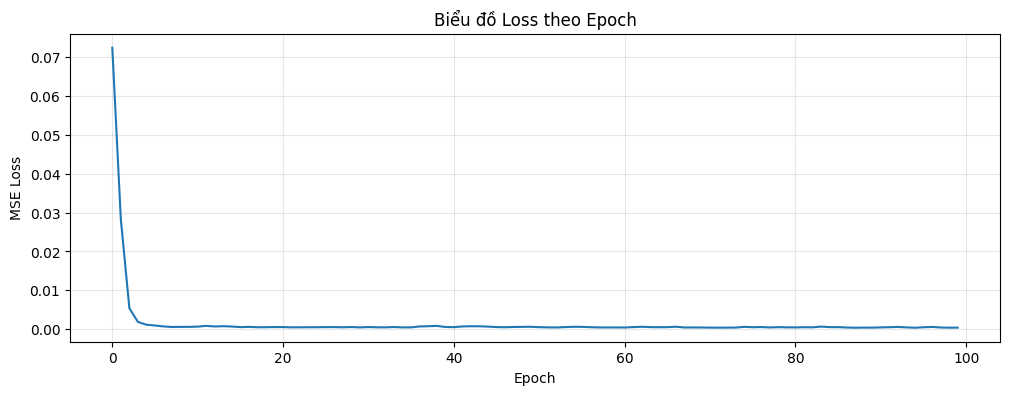

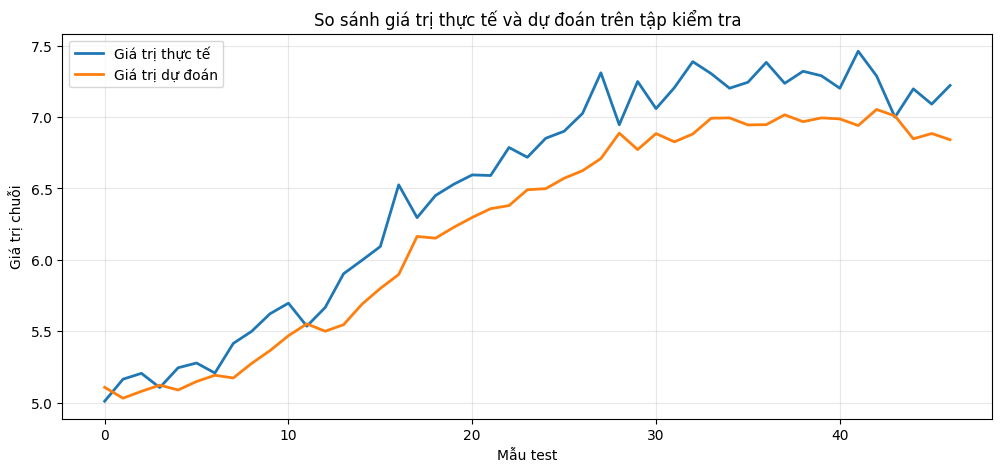

Dự đoán giá trị tiếp theo của chuỗi: 6.8921
5 giá trị dự đoán đầu tiên trên tập test:
  Mẫu 1: thực tế = 5.0103, dự đoán = 5.1077
  Mẫu 2: thực tế = 5.1646, dự đoán = 5.0315
  Mẫu 3: thực tế = 5.2056, dự đoán = 5.0795
  Mẫu 4: thực tế = 5.1060, dự đoán = 5.1228
  Mẫu 5: thực tế = 5.2447, dự đoán = 5.0891


In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# -----------------------------
# 1) Tạo chuỗi thời gian giả lập
# -----------------------------
np.random.seed(42)
torch.manual_seed(42)

steps = np.arange(0, 240)
series = (
    (
        0.5 * np.sin(steps * 0.12)
        + 0.03 * steps
        + 0.2 * np.cos(steps * 0.05)
        + 0.1 * np.random.randn(len(steps))
    )
    .astype(np.float32)
    .reshape(-1, 1)
)

scaler = MinMaxScaler()
scaled_series = scaler.fit_transform(series)

# -----------------------------
# 2) Tạo dữ liệu sliding window
# -----------------------------
window_size = 5
X, y = [], []
for i in range(len(scaled_series) - window_size):
    X.append(scaled_series[i : i + window_size])
    y.append(scaled_series[i + window_size])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True
)


# -----------------------------
# 3) Xây dựng mô hình LSTM
# -----------------------------
class TimeSeriesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


model = TimeSeriesLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# -----------------------------
# 4) Huấn luyện mô hình
# -----------------------------
epochs = 100
loss_history = []
model.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_loader.dataset)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {epoch_loss:.6f}")

# -----------------------------
# 5) Dự đoán trên train/test
# -----------------------------
model.eval()
with torch.no_grad():
    train_pred = model(X_train_t).numpy()
    test_pred = model(X_test_t).numpy()

train_pred_inv = scaler.inverse_transform(train_pred)
test_pred_inv = scaler.inverse_transform(test_pred)
y_train_inv = scaler.inverse_transform(y_train)
y_test_inv = scaler.inverse_transform(y_test)

# -----------------------------
# 6) Trực quan hóa
# -----------------------------
plt.figure(figsize=(12, 4))
plt.plot(loss_history, color="tab:blue")
plt.title("Biểu đồ Loss theo Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label="Giá trị thực tế", linewidth=2)
plt.plot(test_pred_inv, label="Giá trị dự đoán", linewidth=2)
plt.title("So sánh giá trị thực tế và dự đoán trên tập kiểm tra")
plt.xlabel("Mẫu test")
plt.ylabel("Giá trị chuỗi")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 7) Dự đoán giá trị tiếp theo
# -----------------------------
last_window = torch.tensor(scaled_series[-window_size:], dtype=torch.float32).unsqueeze(
    0
)
with torch.no_grad():
    next_pred_scaled = model(last_window).numpy()
next_pred_value = scaler.inverse_transform(next_pred_scaled)[0, 0]

print("Dự đoán giá trị tiếp theo của chuỗi:", round(float(next_pred_value), 4))
print("5 giá trị dự đoán đầu tiên trên tập test:")
for i in range(min(5, len(test_pred_inv))):
    print(
        f"  Mẫu {i + 1}: thực tế = {y_test_inv[i, 0]:.4f}, dự đoán = {test_pred_inv[i, 0]:.4f}"
    )

# Bài 2: Dự đoán từ tiếp theo ở mức đơn giản bằng LSTM

## Yêu cầu
Xây dựng một mô hình LSTM nhỏ để dự đoán từ tiếp theo trong câu.

## Dữ liệu gợi ý
Bạn có thể tùy chọn một trong hai nguồn dữ liệu sau:

**Cách 1: Tự tạo một tập câu ngắn**
Ví dụ:
* "tôi thích nghe nhạc"
* "tôi thích xem phim"
* "bạn thích đọc sách"
* "chúng tôi thích ăn cơm"

**Cách 2: Sử dụng văn bản có sẵn**
Dùng một đoạn văn ngắn tiếng Việt đã được làm sạch các ký tự đặc biệt.


## Nhiệm vụ
Sinh viên thực hiện tuần tự các bước sau để hoàn thành bài tập:

1. **Tiền xử lý văn bản:** * Tách từ (tokenization).
   * Tạo từ điển (vocabulary) từ tập dữ liệu.
   * Biến đổi các câu văn bản thành các chuỗi số (sequences of integers).
2. **Tạo dữ liệu huấn luyện:** Chuẩn bị tập dữ liệu theo định dạng:
   * Đầu vào ($X$): Một chuỗi từ (ngữ cảnh trước đó).
   * Đầu ra ($y$): Từ liền kề tiếp theo.
3. **Xây dựng mô hình:** Thiết lập mạng LSTM để học mẫu ngôn ngữ và dự đoán từ.
4. **Kiểm thử mô hình:** Thử nhập một cụm từ đầu vào (ví dụ: "tôi thích") và in ra kết quả xem mô hình dự đoán từ tiếp theo là gì.

In [2]:
import re
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# -----------------------------
# 1) Dữ liệu câu ngắn
# -----------------------------
sentences = [
    "tôi thích nghe nhạc",
    "tôi thích xem phim",
    "bạn thích đọc sách",
    "chúng tôi thích ăn cơm",
    "tôi thích học sâu",
    "bạn thích chơi bóng",
    "chúng tôi thích đi học",
    "tôi thích ăn trái cây",
]


# -----------------------------
# 2) Tiền xử lý và tạo vocabulary
# -----------------------------
def tokenize(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-zà-ỹ\s]", "", text)
    return text.split()


all_tokens = [tokenize(sentence) for sentence in sentences]
word_counts = Counter(token for tokens in all_tokens for token in tokens)

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
word_to_idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word in sorted(word_counts):
    word_to_idx[word] = len(word_to_idx)
idx_to_word = {idx: word for word, idx in word_to_idx.items()}
vocab_size = len(word_to_idx)

max_len = max(len(tokens) for tokens in all_tokens)
print("Vocabulary:", word_to_idx)
print("Kích thước vocab:", vocab_size)
print("Độ dài câu lớn nhất:", max_len)

Vocabulary: {'<pad>': 0, '<unk>': 1, 'bóng': 2, 'bạn': 3, 'chúng': 4, 'chơi': 5, 'cây': 6, 'cơm': 7, 'học': 8, 'nghe': 9, 'nhạc': 10, 'phim': 11, 'sách': 12, 'sâu': 13, 'thích': 14, 'trái': 15, 'tôi': 16, 'xem': 17, 'ăn': 18, 'đi': 19, 'đọc': 20}
Kích thước vocab: 21
Độ dài câu lớn nhất: 5


In [3]:
# -----------------------------
# 3) Tạo dữ liệu huấn luyện dạng sliding window
# -----------------------------
class NextWordDataset(Dataset):
    def __init__(self, sentences, word_to_idx):
        self.samples = []
        self.word_to_idx = word_to_idx

        for sentence in sentences:
            tokens = tokenize(sentence)
            if len(tokens) < 2:
                continue

            for i in range(1, len(tokens)):
                context = tokens[:i]
                target = tokens[i]
                context_ids = [
                    word_to_idx.get(token, word_to_idx[UNK_TOKEN]) for token in context
                ]
                target_id = word_to_idx.get(target, word_to_idx[UNK_TOKEN])
                self.samples.append((context_ids, target_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        context_ids, target_id = self.samples[index]
        padded_context = context_ids + [word_to_idx[PAD_TOKEN]] * (
            max_len - len(context_ids)
        )
        return (
            torch.tensor(padded_context, dtype=torch.long),
            torch.tensor(target_id, dtype=torch.long),
        )


dataset = NextWordDataset(sentences, word_to_idx)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print("Số mẫu huấn luyện:", len(dataset))
print("Ví dụ 1:", dataset[0])

Số mẫu huấn luyện: 27
Ví dụ 1: (tensor([16,  0,  0,  0,  0]), tensor(14))


In [4]:
# -----------------------------
# 4) Xây dựng mô hình LSTM
# -----------------------------
class NextWordLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=32, hidden_dim=64, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim, padding_idx=word_to_idx[PAD_TOKEN]
        )
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        return self.fc(hidden[-1])


model = NextWordLSTM(vocab_size=vocab_size)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# -----------------------------
# 5) Huấn luyện mô hình
# -----------------------------
torch.manual_seed(42)
loss_history = []
epochs = 200

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for inputs, targets in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)

    avg_loss = total_loss / len(dataset)
    loss_history.append(avg_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_loss:.4f}")

Epoch 50/200 - Loss: 0.3562
Epoch 100/200 - Loss: 0.3373
Epoch 150/200 - Loss: 0.3215
Epoch 200/200 - Loss: 0.3349


In [5]:
# -----------------------------
# 6) Hàm dự đoán từ tiếp theo
# -----------------------------
def encode_context(text):
    tokens = tokenize(text)
    ids = [word_to_idx.get(token, word_to_idx[UNK_TOKEN]) for token in tokens]
    ids = ids[-max_len:]
    ids = ids + [word_to_idx[PAD_TOKEN]] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0)


def predict_next_word(text):
    model.eval()
    input_tensor = encode_context(text)
    with torch.no_grad():
        logits = model(input_tensor)
        predicted_id = torch.argmax(logits, dim=1).item()
    return idx_to_word[predicted_id]


# Kiểm thử mô hình với một cụm từ đầu vào
sample_text = "tôi thích"
predicted_word = predict_next_word(sample_text)
print(f"Đầu vào: '{sample_text}'")
print(f"Từ dự đoán tiếp theo: '{predicted_word}'")

Đầu vào: 'tôi thích'
Từ dự đoán tiếp theo: 'nghe'


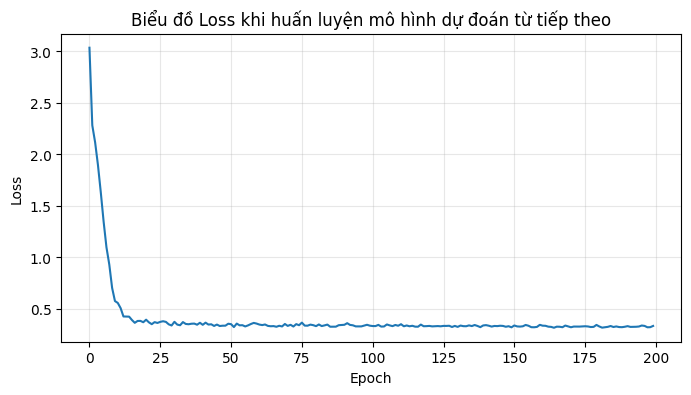

tôi thích -> nghe
bạn thích -> đọc
chúng tôi thích -> ăn


In [6]:
# -----------------------------
# 7) Trực quan hóa loss
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history, color="tab:blue")
plt.title("Biểu đồ Loss khi huấn luyện mô hình dự đoán từ tiếp theo")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

# Một số ví dụ dự đoán thêm
examples = ["tôi thích", "bạn thích", "chúng tôi thích"]
for example in examples:
    print(f"{example} -> {predict_next_word(example)}")